# Nutritional Correlation Analysis (Strict Schema, PySpark)

This notebook computes and visualizes correlations between nutrients in foods using PySpark, with strict schema mapping. Structure and approach follow the nutrient similarity search notebook.

In [7]:
# Imports and Spark session
from pyspark.sql import SparkSession, functions as F
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# In cluster use the HDFS path prefix
path_prefix = "hdfs:///projects/BDA-12/"
# In local use the local path prefix
# path_prefix = "" 

spark = SparkSession.builder.appName("NutritionalCorrelationStrict").getOrCreate()
print("Spark version:", spark.version)

Spark version: 3.5.0


In [8]:
# Configuration
input_path = f"{path_prefix}/output/nutritional_profiles"
output_dir = f"{path_prefix}/output/NutritionalCorrelation"

# Strict schema mapping (edit as needed for your dataset)
schema_columns = {
    'id': 'fdc_id',
    'name': 'food_description',
    'category': 'food_type',
    'energy': 'energy',
    'protein': 'protein',
    'carb': 'carbs',
    'fat': 'total_fat',
    'fiber': 'fiber',
    'sugar': 'sugars',
    'saturated_fat': 'saturated_fat',
    'monounsaturated_fat': 'monounsaturated_fat',
    'polyunsaturated_fat': 'polyunsaturated_fat',
    'trans_fat': 'trans_fat',
    'cholesterol': 'cholesterol',
    'sodium': 'sodium',
    'calcium': 'calcium',
    'iron': 'iron',
    'potassium': 'potassium',
    'vitamin_c': 'vitamin_c',
    'vitamin_a': 'vitamin_a',
    'vitamin_b12': 'vitamin_b12',
}

# Nutrients to include in correlation
nutrient_cols = [
    'energy', 'protein', 'carb', 'fat', 'fiber', 'sugar', 'saturated_fat',
    'monounsaturated_fat', 'polyunsaturated_fat', 'trans_fat', 'cholesterol',
    'sodium', 'calcium', 'iron', 'potassium', 'vitamin_c', 'vitamin_a', 'vitamin_b12'
]

In [9]:
def apply_strict_schema(df, schema_map):
    # Select and rename columns according to schema
    exprs = []
    for k, src in schema_map.items():
        if src in df.columns:
            exprs.append(F.col(src).alias(k))
        else:
            exprs.append(F.lit(None).alias(k))
    return df.select(*exprs)

df_raw = spark.read.parquet(input_path)
df = apply_strict_schema(df_raw, schema_columns)
df.cache(); print(f"Loaded {df.count()} rows.")
df.show(5)

Loaded 1969950 rows.
+------+--------------------+--------------+------+-------+-----+-----+-----+-----+-------------+-------------------+-------------------+---------+-----------+------+-------+----+---------+---------+---------+-----------+
|    id|                name|      category|energy|protein| carb|  fat|fiber|sugar|saturated_fat|monounsaturated_fat|polyunsaturated_fat|trans_fat|cholesterol|sodium|calcium|iron|potassium|vitamin_c|vitamin_a|vitamin_b12|
+------+--------------------+--------------+------+-------+-----+-----+-----+-----+-------------+-------------------+-------------------+---------+-----------+------+-------+----+---------+---------+---------+-----------+
|167516|Waffles, buttermi...|sr_legacy_food|1144.0|   6.58|41.05| 9.22|  2.2|  4.3|        1.898|               4.53|              1.445|     NULL|       15.0| 621.0|  279.0|6.04|    126.0|      0.0|    401.0|       2.86|
|167531|Crackers, cream, ...|sr_legacy_food|1941.0|   7.19|64.88| 19.5|  2.4|10.41|        

In [10]:
# Filter: Optionally restrict to a food category or apply text filters
# Example: df = df.filter(df.category == 'branded_food')
# (Add more filters as needed)

In [11]:
# Prepare for correlation: select only nutrient columns, drop rows with too many missing values
from pyspark.sql.functions import col
min_valid = 3  # require at least 3 non-null nutrients
valid_row = sum([col(c).isNotNull().cast('int') for c in nutrient_cols]) >= min_valid
df_valid = df.where(valid_row)

# Collect to pandas for correlation matrix (PySpark does not have built-in corr matrix)
pdf = df_valid.select(nutrient_cols).toPandas()
corr_matrix = pdf.corr(method='pearson')
corr_matrix

,energy,protein,carb,fat,fiber,sugar,saturated_fat,monounsaturated_fat,polyunsaturated_fat,trans_fat,cholesterol,sodium,calcium,iron,potassium,vitamin_c,vitamin_a,vitamin_b12
energy,1.000000,0.458462,0.635094,0.657000,0.373665,0.495422,0.488915,0.613239,0.479859,0.046927,0.175649,-0.001296,0.019210,0.002373,0.000816,0.002164,0.000617,0.001349
protein,0.458462,1.000000,0.270837,0.323529,0.353096,0.075205,0.195821,0.043582,0.086310,0.012527,0.168688,0.000604,0.032630,0.006950,0.001016,-0.001747,0.007785,-0.002579
carb,0.635094,0.270837,1.000000,0.177186,0.414620,0.774342,0.123114,-0.081410,0.020469,0.045612,0.184085,-0.000621,0.015866,0.004442,-0.000222,0.014262,0.005917,0.008890
fat,0.657000,0.323529,0.177186,1.000000,0.230376,0.140281,0.691315,0.846761,0.667893,0.018707,0.102949,-0.000998,0.016173,0.001750,0.002290,-0.010279,0.000023,-0.004401
fiber,0.373665,0.353096,0.414620,0.230376,1.000000,0.139047,0.090410,0.195858,0.212096,0.011330,0.106018,0.003224,0.026634,0.006331,0.001611,0.016271,0.022824,-0.001861
sugar,0.495422,0.075205,0.774342,0.140281,0.139047,1.000000,0.195024,0.026812,0.019595,0.033122,0.013080,-0.000806,0.016803,0.002902,-0.000282,0.013773,0.004176,0.006147
saturated_fat,0.488915,0.195821,0.123114,0.691315,0.090410,0.195024,1.000000,0.401694,0.306301,0.010014,0.135201,0.000234,0.019062,0.010871,-0.000041,-0.006226,0.002294,-0.004540
monounsaturated_fat,0.613239,0.043582,-0.081410,0.846761,0.195858,0.026812,0.401694,1.000000,0.449668,0.025343,0.000707,0.005132,0.022016,-0.005064,0.042222,0.001453,-0.002262,-0.005881
polyunsaturated_fat,0.479859,0.086310,0.020469,0.667893,0.212096,0.019595,0.306301,0.449668,1.000000,0.018127,-0.001953,0.012802,0.021183,-0.003648,0.041388,0.003990,-0.000591,-0.005690
trans_fat,0.046927,0.012527,0.045612,0.018707,0.011330,0.033122,0.010014,0.025343,0.018127,1.000000,0.002651,-0.000079,0.000047,-0.000024,-0.000039,-0.000477,-0.000546,-0.000537


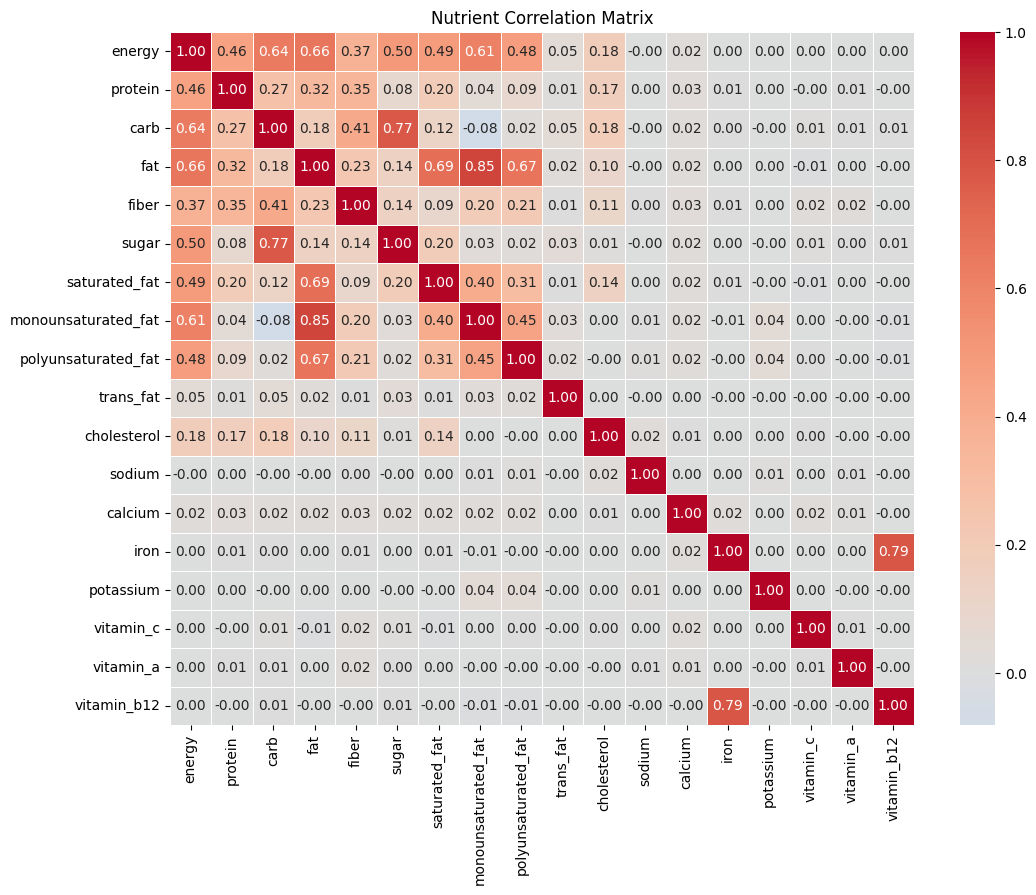

In [12]:
# Visualize correlation matrix as heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Nutrient Correlation Matrix")
plt.show()

In [13]:
# Extract and display strong correlations (|r| > 0.5, off-diagonal)
strong_corrs = []
for i, col1 in enumerate(corr_matrix.columns):
    for j, col2 in enumerate(corr_matrix.columns):
        if i < j:
            val = corr_matrix.iloc[i, j]
            if abs(val) > 0.5:
                strong_corrs.append((col1, col2, val))

# Sort by absolute correlation
strong_corrs = sorted(strong_corrs, key=lambda x: -abs(x[2]))

print("Nutrient pairs with strong correlations (|r| > 0.5):")
for c1, c2, val in strong_corrs:
    print(f"{c1} - {c2}: r = {val:.2f}")

if not strong_corrs:
    print("No strong correlations found.")

Nutrient pairs with strong correlations (|r| > 0.5):
fat - monounsaturated_fat: r = 0.85
iron - vitamin_b12: r = 0.79
carb - sugar: r = 0.77
fat - saturated_fat: r = 0.69
fat - polyunsaturated_fat: r = 0.67
energy - fat: r = 0.66
energy - carb: r = 0.64
energy - monounsaturated_fat: r = 0.61


### Interpretation
- Strong positive correlations may indicate nutrients that often appear together (e.g., sodium and protein in processed meats).
- Negative correlations may suggest substitutions or inverse effects (e.g., fiber vs. sugars in some products).
- These associations can be useful for product development, labeling, or nutritional research.